In [1]:
# Import necessary libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style
sns.set_theme(style="whitegrid")

# Define the file path to the raw dataset
file_path = 'D:/GitFile/Application-of-machine-learning-methods/data/raw/Data_Professional_Salary_Survey_Responses.xlsx'

try:
    # Load the Excel file
    # header=1 skips the first row (index 0) which contains metadata/notes
    df = pd.read_excel(file_path, header=3)
    
    # Remove columns that pandas automatically named "Unnamed" due to empty headers in Excel
    df = df.loc[:, ~df.columns.astype(str).str.contains('^Unnamed')]
    
    # Strip any leading/trailing whitespaces from the column names
    df.columns = df.columns.astype(str).str.strip()
    
    # Display success message and basic dataset information
    print("Data loaded successfully!")
    print(f"Dataset shape (rows, columns): {df.shape}")
    print("\nList of columns after cleaning:")
    print(df.columns.tolist())
    
    # Display the first 5 rows to verify the data structure
    display(df.head())

except Exception as e:
    # Catch and display any errors that occur during the loading process
    print(f"An error occurred while loading the data: {e}")
    print("Please ensure the 'openpyxl' library is installed (!pip install openpyxl).")

Data loaded successfully!
Dataset shape (rows, columns): (14869, 22)

List of columns after cleaning:
['Survey Year', 'Timestamp', 'SalaryUSD', 'Country', 'PostalCode', 'PrimaryDatabase', 'YearsWithThisDatabase', 'OtherDatabases', 'EmploymentStatus', 'JobTitle', 'ManageStaff', 'YearsWithThisTypeOfJob', 'HowManyCompanies', 'OtherPeopleOnYourTeam', 'DatabaseServers', 'PopulationOfLargestCityWithin20Miles', 'EmploymentSector', 'CareerPlansThisYear', 'Gender', 'DataAndServersAreIn', 'MonthsUnemployed', 'Counter']


,Survey Year,Timestamp,SalaryUSD,Country,PostalCode,PrimaryDatabase,YearsWithThisDatabase,OtherDatabases,EmploymentStatus,JobTitle,...,HowManyCompanies,OtherPeopleOnYourTeam,DatabaseServers,PopulationOfLargestCityWithin20Miles,EmploymentSector,CareerPlansThisYear,Gender,DataAndServersAreIn,MonthsUnemployed,Counter
0,2026,2026-01-10 11:03:31.546,132000.0,United States,48,Azure SQL DB,7,Microsoft SQL Server,Full time employee,"Developer: App code (C#, JS, etc)",...,1 (this is the only company where I've had thi...,More than 5,40,300K-1M (large city),Private business,"Stay with the same employer, same role",Male,Azure,NaN,1
1,2026,2026-01-09 17:39:36.563,125000.0,United States,NaN,Microsoft SQL Server,25,"Microsoft SQL Server, Oracle, PostgreSQL, Micr...",Full time employee,Engineer,...,6 or more,More than 5,5,100K-299K (city),Private business,"Stay with the same employer, same role",Female,"Google, Other Cloud Provider, Our Own Data Cen...",NaN,1
2,2026,2026-01-09 16:00:31.730,110000.0,United States,80014,Microsoft SQL Server,10,NaN,Full time employee,Developer: T-SQL,...,1 (this is the only company where I've had thi...,NaN,5,1M+ (metropolis),Private business,"Stay with the same employer, but change roles",Male,AWS,NaN,1
3,2026,2026-01-09 14:42:23.570,130000.0,United States,75063,Microsoft SQL Server,11,Microsoft SQL Server,Full time employee,Developer: T-SQL,...,2 (I worked at another similar position elsewh...,NaN,7,1M+ (metropolis),Private business,"Stay with the same employer, but change roles",Male,"Azure, Our Own Data Centers",NaN,1
4,2026,2026-01-09 10:16:12.649,176000.0,United States,554,Microsoft SQL Server,20,"Microsoft SQL Server, Oracle, PostgreSQL, Micr...",Full time employee,Engineer,...,2 (I worked at another similar position elsewh...,NaN,17,1M+ (metropolis),Private business,"Stay with the same employer, same role",Male,"Azure, Rented Datacenter Space (Colo)",NaN,1


In [2]:
# Display dataset dimensions (rows, columns)
print(f"Dataset shape: {df.shape}\n")

# Display column names, non-null counts, and data types
print("Data types and non-null counts:")
df.info()

# Separate columns into numerical and categorical for easier analysis later
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nNumerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

Dataset shape: (14869, 22)

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14869 entries, 0 to 14868
Data columns (total 22 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   Survey Year                           14869 non-null  int64         
 1   Timestamp                             14869 non-null  datetime64[ns]
 2   SalaryUSD                             14869 non-null  float64       
 3   Country                               14869 non-null  object        
 4   PostalCode                            11796 non-null  object        
 5   PrimaryDatabase                       14869 non-null  object        
 6   YearsWithThisDatabase                 14869 non-null  int64         
 7   OtherDatabases                        12171 non-null  object        
 8   EmploymentStatus                      14869 non-null  object        
 9   JobTitle    

Columns with missing values:


,Missing Values,Percentage (%)
MonthsUnemployed,14773,99.354361
DataAndServersAreIn,13854,93.173717
OtherPeopleOnYourTeam,5550,37.325980
PostalCode,3073,20.667160
OtherDatabases,2698,18.145134
Gender,1,0.006725


C:\Users\n1107\AppData\Local\Temp\ipykernel_85816\2719871683.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df.index, y=missing_df['Percentage (%)'], palette='viridis')


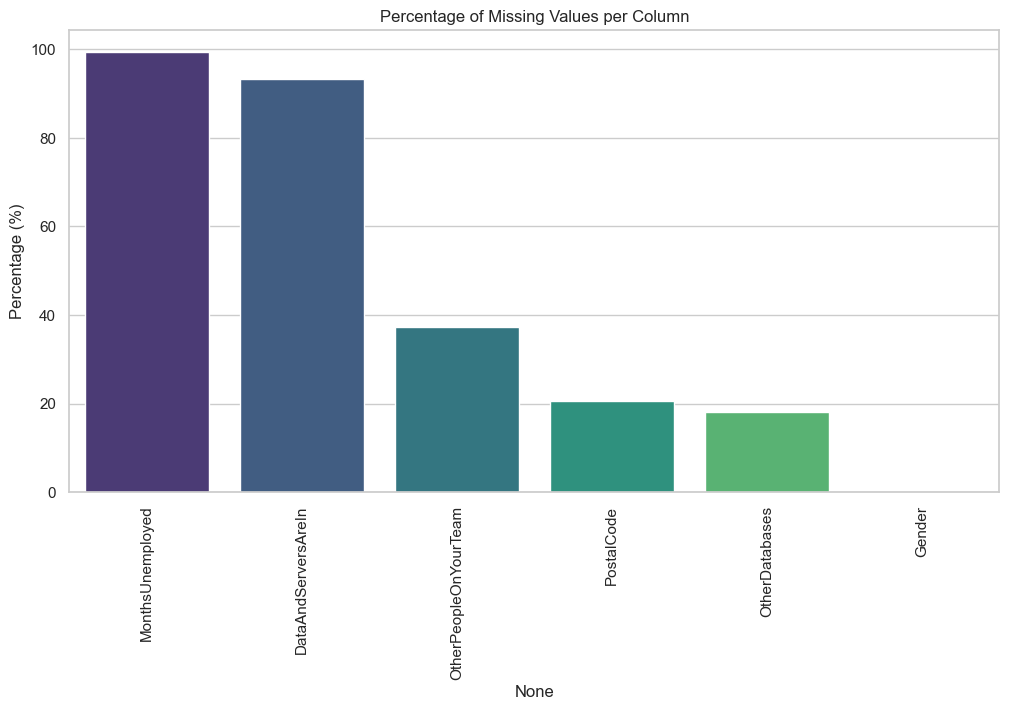

In [3]:
# Calculate the percentage of missing values for each column
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

# Create a DataFrame to display missing values clearly
missing_df = pd.DataFrame({'Missing Values': missing_data, 'Percentage (%)': missing_percentage})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False)

print("Columns with missing values:")
display(missing_df)

# Visualize missing data using a bar plot for columns with missing values
if not missing_df.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=missing_df.index, y=missing_df['Percentage (%)'], palette='viridis')
    plt.xticks(rotation=90)
    plt.title('Percentage of Missing Values per Column')
    plt.ylabel('Percentage (%)')
    plt.show()

In [4]:
# Generate descriptive statistics for numerical variables
print("Descriptive statistics for numerical variables:")
display(df.describe())

# Generate descriptive statistics for categorical variables
print("\nDescriptive statistics for categorical variables:")
display(df.describe(include=['object']))

Descriptive statistics for numerical variables:


,Survey Year,Timestamp,SalaryUSD,YearsWithThisDatabase,YearsWithThisTypeOfJob,MonthsUnemployed,Counter
count,14869.000000,14869,1.486900e+04,14869.000000,14869.000000,96.000000,14869.0
mean,2020.281122,2020-04-01 02:58:16.296005120,1.007982e+05,19.906719,9.639384,16.453125,1.0
min,2017.000000,2017-01-05 05:10:20.451000,1.300000e+01,0.000000,0.000000,0.000000,1.0
25%,2018.000000,2017-12-14 07:36:39.012000,6.900000e+04,6.000000,3.000000,1.375000,1.0
50%,2020.000000,2019-12-11 15:36:03.180000,9.600000e+04,10.000000,7.000000,5.000000,1.0
75%,2022.000000,2021-12-10 06:24:52.383000064,1.250000e+05,17.000000,13.000000,12.000000,1.0
max,2026.000000,2026-01-10 11:03:31.546000,1.850000e+06,53716.000000,2020.000000,204.000000,1.0
std,2.873474,NaN,6.151424e+04,510.304660,33.694479,34.818407,0.0



Descriptive statistics for categorical variables:


,Country,PostalCode,PrimaryDatabase,OtherDatabases,EmploymentStatus,JobTitle,ManageStaff,HowManyCompanies,OtherPeopleOnYourTeam,DatabaseServers,PopulationOfLargestCityWithin20Miles,EmploymentSector,CareerPlansThisYear,Gender,DataAndServersAreIn
count,14869,11796,14869,12171,14869,14869,14869,14869,9319,14869,14869,14869,14869,14868,1015
unique,103,4956,15,2541,6,23,2,7,6,325,6,7,6,5,47
top,United States,Not Asked,Microsoft SQL Server,Microsoft SQL Server,Full time employee,DBA (General - splits time evenly between writ...,No,Not Asked,1,Not Asked,Not Asked,Private business,"Stay with the same employer, same role",Male,Our Own Data Centers
freq,9593,2898,13669,1278,13132,3238,11398,5992,3056,1747,5992,12234,7395,10532,181


C:\Users\n1107\AppData\Local\Temp\ipykernel_85816\3626140424.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


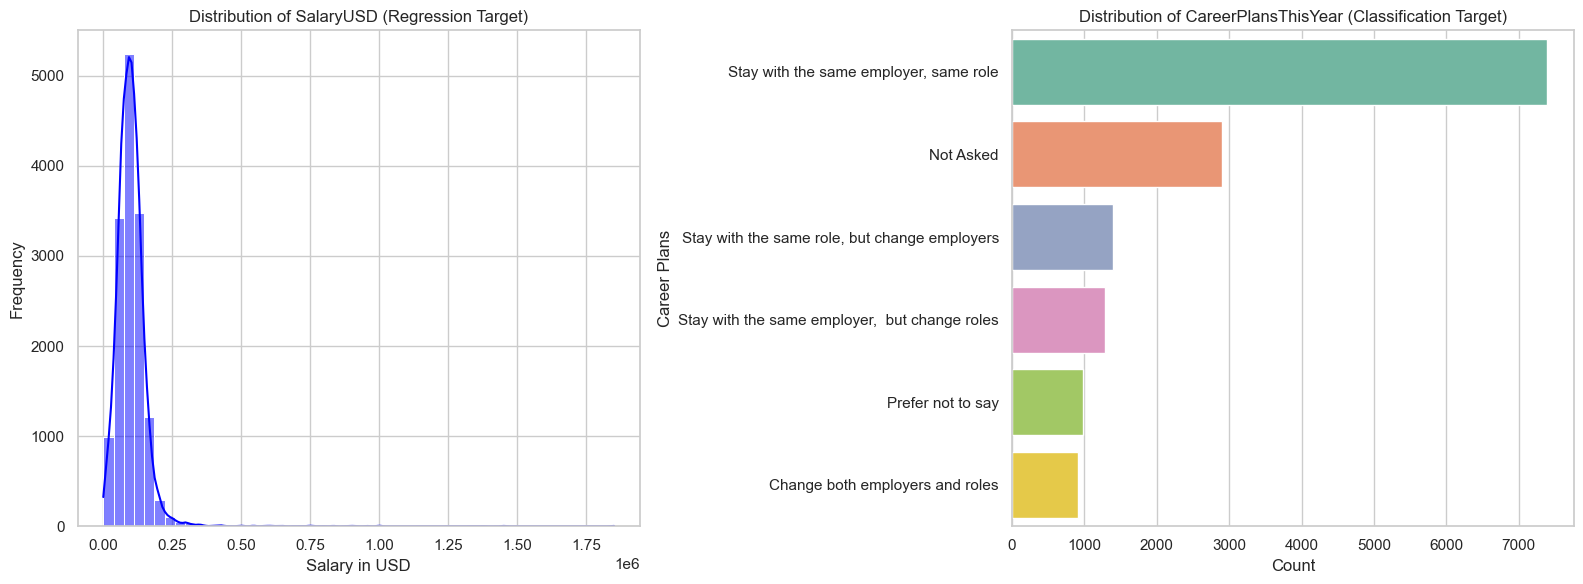

In [5]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Distribution of the continuous target variable: SalaryUSD
if 'SalaryUSD' in df.columns:
    sns.histplot(df['SalaryUSD'].dropna(), bins=50, kde=True, ax=axes[0], color='blue')
    axes[0].set_title('Distribution of SalaryUSD (Regression Target)')
    axes[0].set_xlabel('Salary in USD')
    axes[0].set_ylabel('Frequency')
else:
    axes[0].text(0.5, 0.5, 'SalaryUSD column not found', ha='center', va='center', fontsize=14, color='red')
    axes[0].set_title('Distribution of SalaryUSD')

# 2. Dynamic check for the career plans column to prevent KeyError
# We look for a column that contains 'CareerPlans' in its name
career_col = [col for col in df.columns if 'CareerPlans' in col]

if career_col:
    target_career_col = career_col[0] # Take the matched column name
    
    # Plot the distribution of the categorical target variable
    sns.countplot(
        data=df, 
        y=target_career_col, 
        ax=axes[1], 
        order=df[target_career_col].value_counts().index, 
        palette='Set2'
    )
    axes[1].set_title(f'Distribution of {target_career_col} (Classification Target)')
    axes[1].set_xlabel('Count')
    axes[1].set_ylabel('Career Plans')
else:
    # If no matching column is found, display a warning message on the plot
    axes[1].text(0.5, 0.5, 'CareerPlans column not found', ha='center', va='center', fontsize=14, color='red')
    axes[1].set_title('Distribution of Career Plans')

plt.tight_layout()
plt.show()

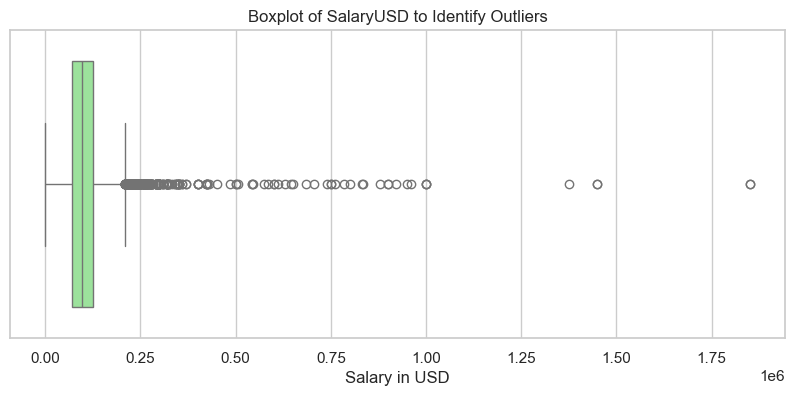

Statistically defined outliers in SalaryUSD (using IQR method): 312 observations


In [6]:
# Identify outliers in the target variable SalaryUSD using a Boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['SalaryUSD'], color='lightgreen')
plt.title('Boxplot of SalaryUSD to Identify Outliers')
plt.xlabel('Salary in USD')
plt.show()

# Calculate Interquartile Range (IQR) to mathematically define outliers for SalaryUSD
Q1 = df['SalaryUSD'].quantile(0.25)
Q3 = df['SalaryUSD'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count = df[(df['SalaryUSD'] < lower_bound) | (df['SalaryUSD'] > upper_bound)].shape[0]
print(f"Statistically defined outliers in SalaryUSD (using IQR method): {outliers_count} observations")

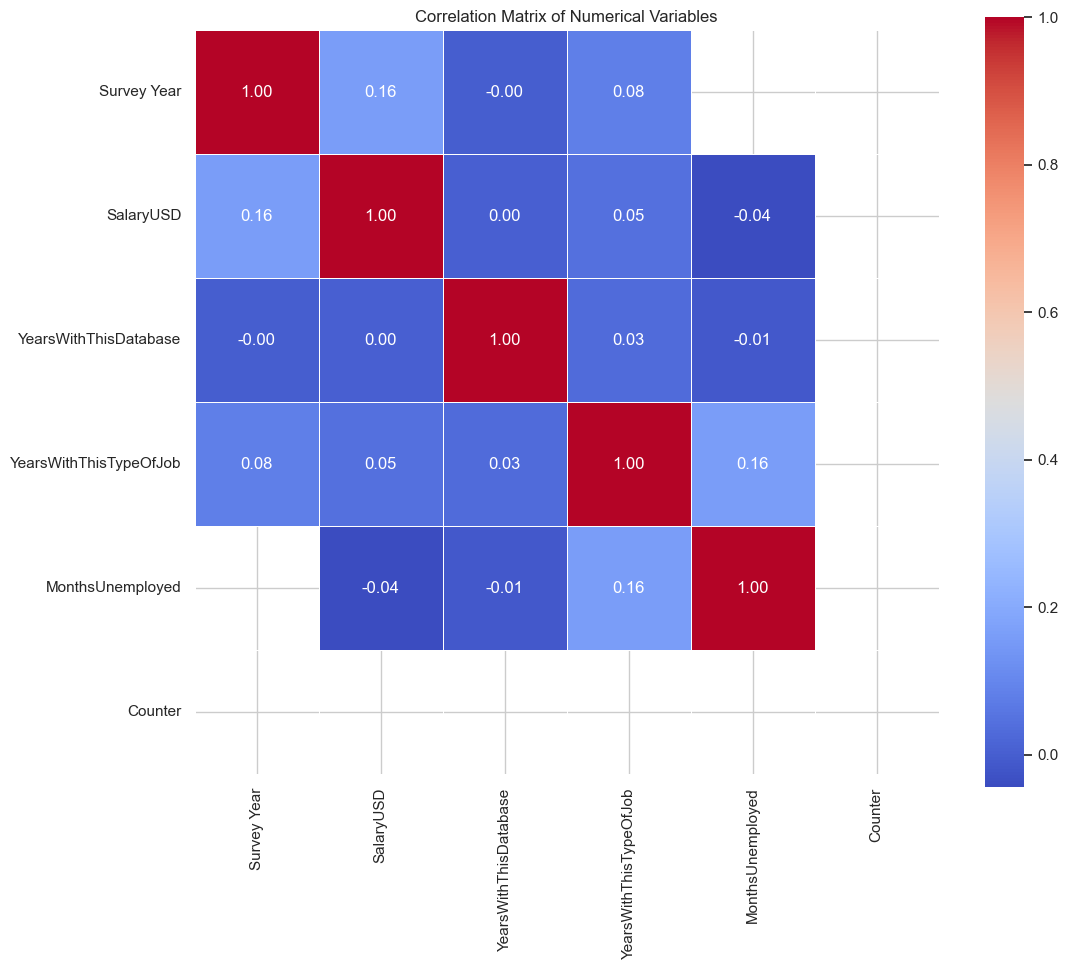

Correlation of numerical features with SalaryUSD:
SalaryUSD                 1.000000
Survey Year               0.162790
YearsWithThisTypeOfJob    0.045008
YearsWithThisDatabase     0.002833
MonthsUnemployed         -0.044301
Counter                        NaN
Name: SalaryUSD, dtype: float64


In [7]:
# Calculate the correlation matrix for numerical variables only
corr_matrix = df[numerical_cols].corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

# Display correlations specifically with the target variable SalaryUSD
if 'SalaryUSD' in corr_matrix.columns:
    target_corr = corr_matrix['SalaryUSD'].sort_values(ascending=False)
    print("Correlation of numerical features with SalaryUSD:")
    print(target_corr)

In [8]:
print(df.columns.tolist())

['Survey Year', 'Timestamp', 'SalaryUSD', 'Country', 'PostalCode', 'PrimaryDatabase', 'YearsWithThisDatabase', 'OtherDatabases', 'EmploymentStatus', 'JobTitle', 'ManageStaff', 'YearsWithThisTypeOfJob', 'HowManyCompanies', 'OtherPeopleOnYourTeam', 'DatabaseServers', 'PopulationOfLargestCityWithin20Miles', 'EmploymentSector', 'CareerPlansThisYear', 'Gender', 'DataAndServersAreIn', 'MonthsUnemployed', 'Counter']
